# 8. pycisTarget loop-DMR motif enrichment

Part of the **[Fig. 5 chapter](fig5.md)** — produces the **Fig 5H** (major-type loop vs non-loop DMR motif dot plot) and **Fig 6G** (Mus Skl loop-DMR motif) panels via pycisTarget/SCENIC+. *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{ENTEX_ROOT}/L1color.tsv'`  ·  _metadata: color_
- `f'{REF_ROOT}/aertslab_motif_colleciton/v10nr_clust_public/snapshots/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl'`  ·  _reference_
- `'loop_peak_motif/majortype_merged_loop_TF_all.hdf'`  ·  _loop calls_
- `f'{REF_ROOT}/yin_2017_motif_type.csv'`  ·  _reference_
- `'loop_dmr_motif/pycistarget_majortype_merged_loopdmr_TF_all.hdf'`  ·  _loop calls_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')
import repro_guard

In [1]:
#pip install lxml html5lib beautifulsoup4
import pandas as pd
import seaborn as sns
from scipy.stats import zscore
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from glob import glob
from collections import defaultdict
mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [2]:
#tf2call['Call'].unique()
callmap = {'MethylPlus':'MethylPlus', 
 'MethylMinus':'MethylMinus', 
 'Little effect and MethylMinus':'Little effect',
       'MethylMinus and MethylPlus':'Little effect', 
 'Little effect and MethylPlus':'Little effect',
       'MethylPlus and Little effect':'Little effect', 
 'MethylMinus and Little effect':'Little effect',
       'MethylPlus and MethylMinus':'MethylPlus', 
 'Little effect':'Little effect', 
 'inconclusive':'no info'}

In [24]:
L1_meta = pd.read_csv(f'{ENTEX_ROOT}/L1color.tsv', sep='\t', header=0, index_col=0)
# L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_meta = L1_meta.drop(['c7'], axis=0)
# L1_annot = L1_meta['L1_abbr'].to_dict()
# L1_color = L1_meta['color'].to_dict()
majortype2annot = L1_meta['L1_abbr'].to_dict()


In [8]:
df = df[df['group']=='summit']

In [10]:
jaspr_meta = pd.read_csv(f'{REF_ROOT}/yin_2017_motif_type.csv')
jaspr_meta.index = jaspr_meta['TF name']
#jaspr_meta = jaspr_meta[~jaspr_meta['TF name'].isna()]

In [11]:
jaspr_meta['Call'] = jaspr_meta['Call'].map(callmap)
tf2call = jaspr_meta[jaspr_meta['TF name'].isin(df['gene'].unique())][['TF name','Call']].drop_duplicates()
tf2call.index = tf2call['TF name']
tf2call = tf2call['Call'].to_dict()
tmp = jaspr_meta[['TF name', 'Call']].dropna(axis=0)
tmp.index = tmp['TF name']
tf2call = tmp['Call'].to_dict()

for g in list(df['gene'].unique()):
    if not g in tf2call.keys():
        tf2call[g]='no info'

In [18]:
import matplotlib.cm as cm
colors = cm.get_cmap('tab20', 15)
color_map = {c:colors(i) for i,c in enumerate(np.unique(list(tf2call.values()))) }
color_map = {'Little effect': 'brown',
 'MethylMinus': 'blue',
 'MethylPlus': 'red',
 'no info': 'black'}

/tmp/ipykernel_3394929/1852574109.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', 15)


# loop DMR

# homer loop dmr

In [145]:
# Specify the path to your HTML file or a URL
col = ['Motif Name', 'Consensus', 'P-value', 'Log P-value',
       'q-value (Benjamini)', '# of Target Sequences with Motif',
       '% of Target Sequences with Motif',
       '# of Background Sequences with Motif',
       '% of Background Sequences with Motif']
tmpdf = []
for file_path in glob('loop_dmr_motif/homer/*txt'):
    tmp = pd.read_csv(file_path,sep='\t') 
    tmp.columns = col
    tmp['majortype'] = file_path.split('/')[-1].split('_')[0]
    tmpdf.append(tmp)
df = pd.concat(tmpdf,axis=0)
df['gene'] = [i.split('/')[0].split('(')[0] for i in df['Motif Name']]
df['TF family'] = [i.split(')')[0].split('(')[-1] for i in df['Motif Name']]
df['-Log P-value'] = -df['Log P-value']

In [150]:
selg = []
tmp_df = df[df['-Log P-value']>7]
for cluster in tmp_df['majortype'].unique():
    selg += list(df[df['majortype']==cluster].sort_values('-Log P-value',ascending=False)['gene'][:5].values)
selg = np.unique(selg)
len(selg)

67

In [151]:
tf2call = jaspr_meta[jaspr_meta['TF name'].isin(df['gene'].unique())][['TF name','Call']].drop_duplicates()
tf2call.index = tf2call['TF name']
tf2call = tf2call['Call'].to_dict()
tmp = jaspr_meta[['TF name', 'Call']].dropna(axis=0)
tmp.index = tmp['TF name']
tf2call = tmp['Call'].to_dict()

for g in list(df['gene'].unique()):
    if not g in tf2call.keys():
        tf2call[g]='no info'

In [152]:
df = df.set_index(['gene', 'majortype'])
df = df.loc[~df.index.duplicated(keep='first')]
col='-Log P-value'
df[col].unstack().fillna(0)

majortype,c0,c1,c10,c11,c12,c13,c14,c15,c16,c17,...,c32,c33,c34,c35,c36,c4,c5,c6,c8,c9
gene,,,,,,,,,,,,,,,,,,,,,
AMYB,0.5228,10.8700,10.660000,1.1490,3.0490,7.1980,2.1990,3.223000,6.12600,1.989000,...,2.2660,10.0200,0.9310,1.2890,0.08799,1.8810,0.19090,1.013,2.3820,2.9400
AP-1,18.3200,67.2400,0.000129,8.6460,9.5600,11.3900,8.4230,1.159000,0.09909,60.280000,...,20.4700,14.4600,1.0510,0.9265,4.15000,5.9320,3.47300,13.530,4.1240,71.0100
AP-2alpha,1.9940,7.5560,8.966000,3.8460,9.1420,6.6800,2.8080,2.726000,3.62400,11.340000,...,2.7350,2.1020,0.7556,1.1630,2.37600,12.3300,3.27900,5.196,4.2290,10.0200
AP-2gamma,6.4180,12.2900,11.320000,4.4950,9.4410,11.2500,2.0980,3.265000,7.98300,19.650000,...,5.9470,1.1130,0.8833,0.9494,2.19700,11.7800,2.30200,9.403,4.7500,11.3200
AR-halfsite,1.6360,2.6030,5.968000,5.6090,3.7690,13.0800,14.2000,2.605000,5.17100,18.560000,...,2.2610,1.9680,1.2630,0.4482,2.67900,8.5050,1.21300,2.523,1.7170,2.6140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c-Myc,1.7040,2.4820,4.905000,3.7090,2.7380,5.5410,3.2600,0.378800,2.15900,12.850000,...,1.6330,2.4550,5.2430,0.7574,1.36600,3.8900,0.86820,7.013,1.3880,0.3151
n-Myc,1.0250,0.3023,6.805000,1.6990,0.4654,5.5210,2.6690,0.194100,1.57000,9.759000,...,0.3280,1.2050,3.0410,0.3022,1.10500,4.0200,0.58450,8.571,1.1190,0.0228
p53,1.6330,0.4064,0.930800,2.6120,1.7870,0.5653,0.6560,0.206700,1.63000,0.101100,...,0.2928,0.8197,2.3480,0.1718,3.75600,1.0860,0.86150,4.799,1.4430,1.0680


In [153]:
melted_df_list = {}
#selg = []
nes = None
auc = None
for col in [ '-Log P-value','# of Target Sequences with Motif']:
    tmp = df[col].unstack().fillna(0)
    if col in ['-Log P-value']:
        data = zscore(tmp.loc[selg], axis=0)
        #data = tmp.loc[selg]
        nes = data.loc[selg]
        melted_data = data.loc[selg].melt(var_name='cluster_Name', value_name=col, ignore_index=False)
        g = sns.clustermap(data.loc[selg], metric='cosine',  z_score=0,vmin=0,vmax=3 ) #metric='cosine',z_score=0,  vmin=0,vmax=3, 
        rorder = g.dendrogram_row.reordered_ind
        corder = g.dendrogram_col.reordered_ind
    else:  
        data = zscore(zscore(tmp.loc[selg], axis=0), axis=1)
        #data = tmp.loc[selg]
        melted_data = tmp.loc[selg].melt(var_name='cluster_Name', value_name=col, ignore_index=False)
        sns.clustermap(data.loc[selg], metric='cosine',  z_score=0,vmin=0,vmax=3,col_cluster=False  ) #metric='cosine',  z_score=0,vmin=0,vmax=3, 
        #if col == 'AUC':
            
    plt.title(col)
    melted_df_list[col] = melted_data.copy()
    

In [154]:
melted_df = melted_df_list['-Log P-value'][['cluster_Name']]
for col in [ '-Log P-value','# of Target Sequences with Motif']:
    melted_df[col] = melted_df_list[col][col]
melted_df['Motif_hits'] = np.log10(melted_df['# of Target Sequences with Motif']+1)
melted_df = melted_df.loc[selg]
melted_df = melted_df.reset_index()

melted_df['cluster_Name'] = pd.Categorical(melted_df['cluster_Name'], categories=nes.columns[corder], ordered=True)
melted_df['gene'] = pd.Categorical(melted_df['gene'], categories=nes.index[rorder], ordered=True)

#melted_df = melted_df[melted_df['Rank_at_max']>0]
melted_df.shape

(2412, 5)

/tmp/ipykernel_3753262/2673172641.py:22: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes.set_xticklabels(nes.columns[corder].map(majortype2annot), fontsize=8, rotation=90)


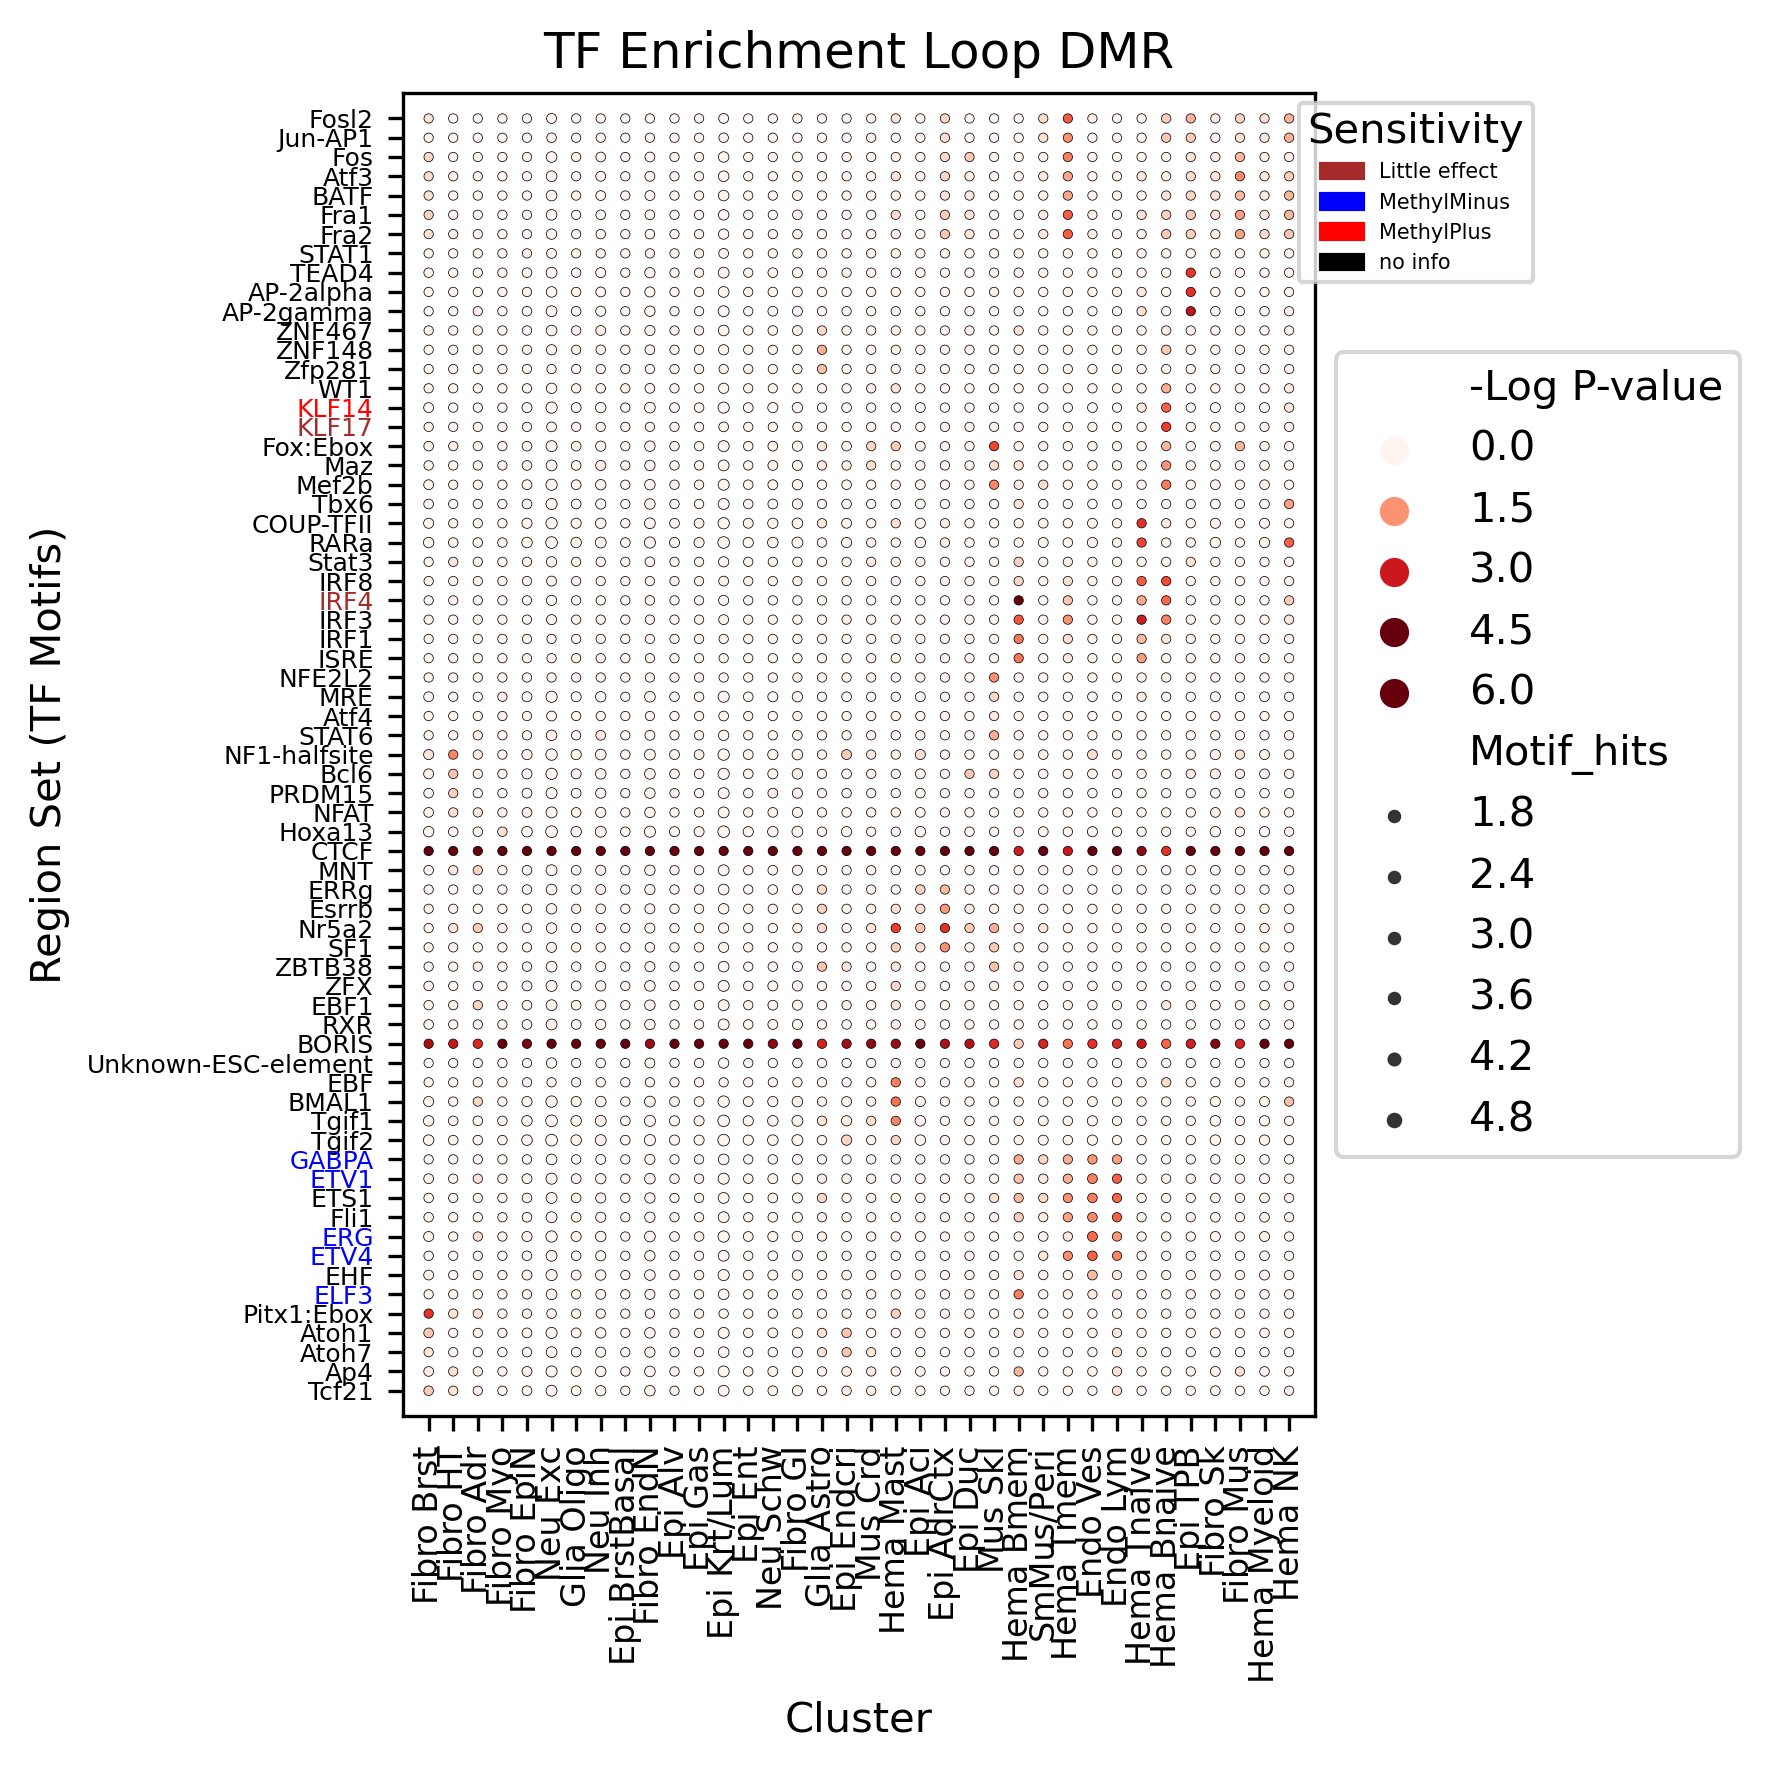

In [156]:
#sel 5 genes from each cluster
import matplotlib.patches as mpatches
# for size  in ['Rank_at_max','Motif_hits']:
fig, axes = plt.subplots(1, 1, figsize=(6,6), dpi=300)
dotplot = sns.scatterplot(
    data=melted_df,
    x='cluster_Name',
    y='gene',
    size='Motif_hits',
    hue='-Log P-value',
    palette='Reds',
    edgecolor='k',
    sizes=(5, 20),
    hue_norm=(0, 4),
    size_norm=(4, 9),
    ax=axes,
    rasterized=True
)

plt.title('TF Enrichment Loop DMR')
plt.xlabel('Cluster')
axes.set_xticklabels(nes.columns[corder].map(majortype2annot), fontsize=8, rotation=90)
axes.set_yticks([i for i,x in enumerate(nes.index[rorder]) ])
axes.set_yticklabels([x for i,x in enumerate(nes.index[rorder]) ], fontsize=6)
 

for label in axes.get_yticklabels():
    gene = label.get_text()  # Get the gene name
    if gene in tf2call:  # Ensure the gene exists in mapping
        label.set_color(color_map[tf2call[gene]])  # Set label color
    label.set_fontsize(6)

    # Add a color legend for `color_map`
legend_patches = [mpatches.Patch(color=color, label=category) for category, color in color_map.items()]
legend = plt.legend(handles=legend_patches, title="Sensitivity", loc='upper right',fontsize=5, bbox_to_anchor=(1.25, 1))
plt.gca().add_artist(legend)  # Ensure legend does not overlap with the main plot

plt.ylabel('Region Set (TF Motifs)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.margins(x=0.03, y=0.02)
#plt.colorbar(label='NES')
fig.savefig(f'TF_overlapped_nes_mus_long_methyltype.pdf', transparent=True)
